<a href="https://colab.research.google.com/github/Eliezer-Carvalho/Tiny-GPT/blob/main/Transformer%20-%20Attention%20Is%20All%20You%20Need.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Transformers**
<hr>

Os Transformers são uma arquitetura de Redes Neurais baseada no mecanismo <b> Attention</b>. <br>
Esta abordagem foi proposta em 2017 no artigo <b><i> ["Attention Is All You Need"](https://arxiv.org/pdf/1706.03762) </i></b> e desde então revolucionou o campo da Inteligência Artificial. <br>
Uma das maiores provas do impacto dos Transformers é o surgimento de modelos como: <br>

*    <b> [GPT](https://en.wikipedia.org/wiki/Generative_pre-trained_transformer) <i>(Generative Pre-trained Transformer)</i> </b>
*    <b> [BERT](https://en.wikipedia.org/wiki/BERT_(language_model)) <i>(Bidirectional Encoder Representations from Transformers)</i></b>









O objetivo deste Google Colab é explorar de forma prática a arquitetura dos Transformers. <br>
Ao longo do notebook, iremos percorrer as suas principais componentes construindo gradualmente a intuição por trás do modelo. <br>



---



In [2]:
!wget https://raw.githubusercontent.com/Eliezer-Carvalho/Tiny-GPT/refs/heads/main/data/Dataset%20Tiny%20Stories.txt

--2026-05-12 19:42:18--  https://raw.githubusercontent.com/Eliezer-Carvalho/Tiny-GPT/refs/heads/main/data/Dataset%20Tiny%20Stories.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12165003 (12M) [text/plain]
Saving to: ‘Dataset Tiny Stories.txt’

Dataset Tiny Storie 100%[===================>]  11.60M  --.-KB/s    in 0.1s    

2026-05-12 19:42:18 (109 MB/s) - ‘Dataset Tiny Stories.txt’ saved [12165003/12165003]



### <b> 1. Tokenização </b>
Os Transformers consistem em operações sobre números. <br>
Para tal, deve haver primeiro um mapeamento de qualquer texto de entrada para representação numérica. <br>

A <b> Tokenização </b> divide o texto em pequenos fragmentos chamados <b> tokens</b>. <br>
Um token pode ser uma palavra inteira, parte de uma palavra ou até mesmo um sinal de pontuação. <br>

A forma como essa divisão é feita depende principalmente dos **[Algoritmos de Tokenização](https://huggingface.co/docs/transformers/tokenizer_summary)**. <br>
Entre os mais comuns estão:

*   **BPE (*Byte Pair Encoding*)**
*   **Unigram**
*   **SentencePiece**
*   **WordPiece**
*   **Word-Level Tokenization**
*   **Character-Level Tokenization**



Diferentes algoritmos produzem diferentes tokenizações, o que pode impactar o desempenho do modelo. <br>

Existem também os <b> [Pré Tokenizers](https://huggingface.co/docs/tokenizers/api/pre-tokenizers) </b> que aplicam uma transformação especial no dataset antes de aplicar o Algoritmo de Tokenização. <br>
<b> Pela minha experiência, nem sempre um Pré Tokenizer traz vantagens. </b> <br>


#### <b> Análise do Dataset </b>

In [3]:
import re   #https://pypi.org/project/regex/

with open ("Dataset Tiny Stories.txt", "r", encoding = "utf-8") as f:
  dataset = f.read()

#https://regexbox.com/cheatsheet
print (f"Caractéres --> {len(dataset)}")
print (f"Palavras --> {len(re.findall(r'\w+', dataset))}")
print (f"Linhas --> {len(re.findall(r'\n', dataset))}")

Caractéres --> 12165003
Palavras --> 2447271
Linhas --> 81035


#### <b> Tokenizer </b>

<b> Neste projeto, criámos o nosso próprio Tokenizer de raiz! </b> <br>
Não é algo obrigatório, é possível usar Tokenizers já existentes. <br>

Esta ideia surgiu, porque para cada dataset poderá ser necessário adaptar um Tokenizer para conseguir ter uma boa Tokenização. <br>
É fulcral entender que esta etapa, apesar de por vezes ser passada ao lado, é uma <b>etapa de extrema importância, pois define a estrutura da Linguagem que o modelo vai aprender</b>.

No meu caso em específico, era perfeitamente possível utilizar um Tokenizer comum (<i>gpt</i> ou <i>bert</i>) pois estes são treinados com gigas e mais gigas de datasets predominantemente da Língua Inglesa porém <b> Where's the fun ? ;)</b>

Se tivesse um dataset mais específico com Linguagens antigas ou até mesmo Línguas como o Chinês, <b> seria obrigatório criar um Tokenizer de raiz.</b> <br>

E a ideia que quero deixar, é esta: <br>
<b> A Tokenização é uma fase bastante importante em modelos de Processamento de Linguagem Natural. Consoante o dataset e o tipo de objetivo, é necessário fazer uma análise e avaliação de qual é a melhor opção a tomar. </b>

In [9]:
from tokenizers import Tokenizer #https://huggingface.co/docs/tokenizers/index
from tokenizers.models import BPE #https://huggingface.co/docs/tokenizers/api/models
from tokenizers.trainers import BpeTrainer #https://huggingface.co/docs/tokenizers/api/trainers
from tokenizers.pre_tokenizers import Metaspace, Punctuation, Whitespace, WhitespaceSplit #https://huggingface.co/docs/tokenizers/api/pre-tokenizers
import matplotlib.pyplot as plt

#### **Tokenização não é algo Perfeito!**

> <i> Como é que eu sei que o meu Tokenizer funciona ? Que é o adequado para o meu dataset? Como posso avaliar o meu Tokenizer ? </i>

Não há uma resposta correta! Mas há maneiras de chegar a um bom resultado!

O Algoritmo de Tokenização que selecionei para este estudo foi o <b> BPE </b>, tentei também aplicar <b> Unigram </b> mas por motivos de custos computacionais não foi possível prosseguir.

<b> O estudo consiste na análise de vários Tokenizers BPE com diferentes técnicas de Pré-Tokenizers e números de Vocab_Size distintos. </b> <br>
A maneira como avaliei estes Algoritmos baseia-se em duas métricas:

*   <b> Fertility </b> <br>
**[Fertility](https://arxiv.org/pdf/2310.08754)** é definida como o número médio de tokens necessários para representar uma palavra. <br>
Tem de ser SEMPRE > 1, se for < 1, o Tokenizer não serve! <br>
Pode ser representada matemáticamente como:

$$
\frac {\text{Número de Tokens}} {\text{Número de Palavras no Dataset}}
$$
<br>


*   <b> Coverage Visual </b> <br>
Baseia-se na capacidade de observar se o Tokenizer consegue transformar uma frase de teste em tokens de maneira eficiente!




##### **BPE**

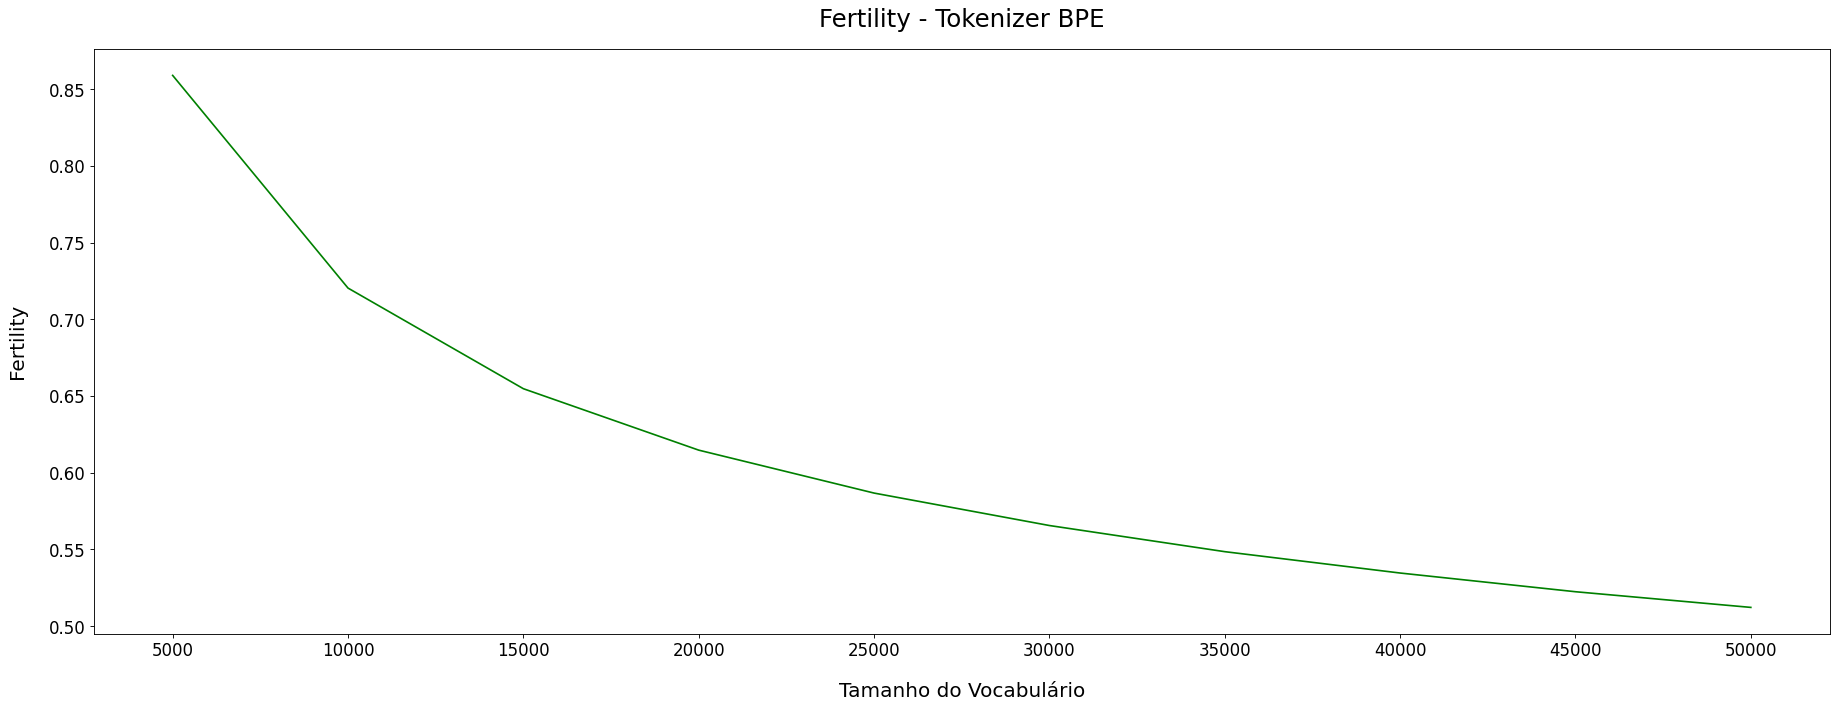


TOKENIZAÇÃO DOS DIFERENTES TOKENIZERS BPE

One day, a boy named Tim went to the park to play. He saw his friend, Sam, playing with a toy car.

(BPE, 5000) -> ['One day, a boy named Tim ', 'went to the park to play', '. He ', 'saw his ', 'friend, Sam, ', 'playing ', 'with a ', 'toy car', '.']
(BPE, 10000) -> ['One day, a boy named Tim ', 'went to the park to play', '. He ', 'saw his ', 'friend, Sam, ', 'playing with a ', 'toy car', '.']
(BPE, 15000) -> ['One day, a boy named Tim ', 'went to the park to play', '. He saw his ', 'friend, Sam, ', 'playing with a ', 'toy car', '.']
(BPE, 20000) -> ['One day, a boy named Tim ', 'went to the park to play', '. He saw his ', 'friend, Sam, ', 'playing with a ', 'toy car', '.']
(BPE, 25000) -> ['One day, a boy named Tim ', 'went to the park to play', '. He saw his ', 'friend, Sam, ', 'playing with a ', 'toy car', '.']
(BPE, 30000) -> ['One day, a boy named Tim ', 'went to the park to play', '. He saw his ', 'friend, Sam, ', 'playing with a ', 'to

In [14]:
t

##### **Metaspace -> BPE**

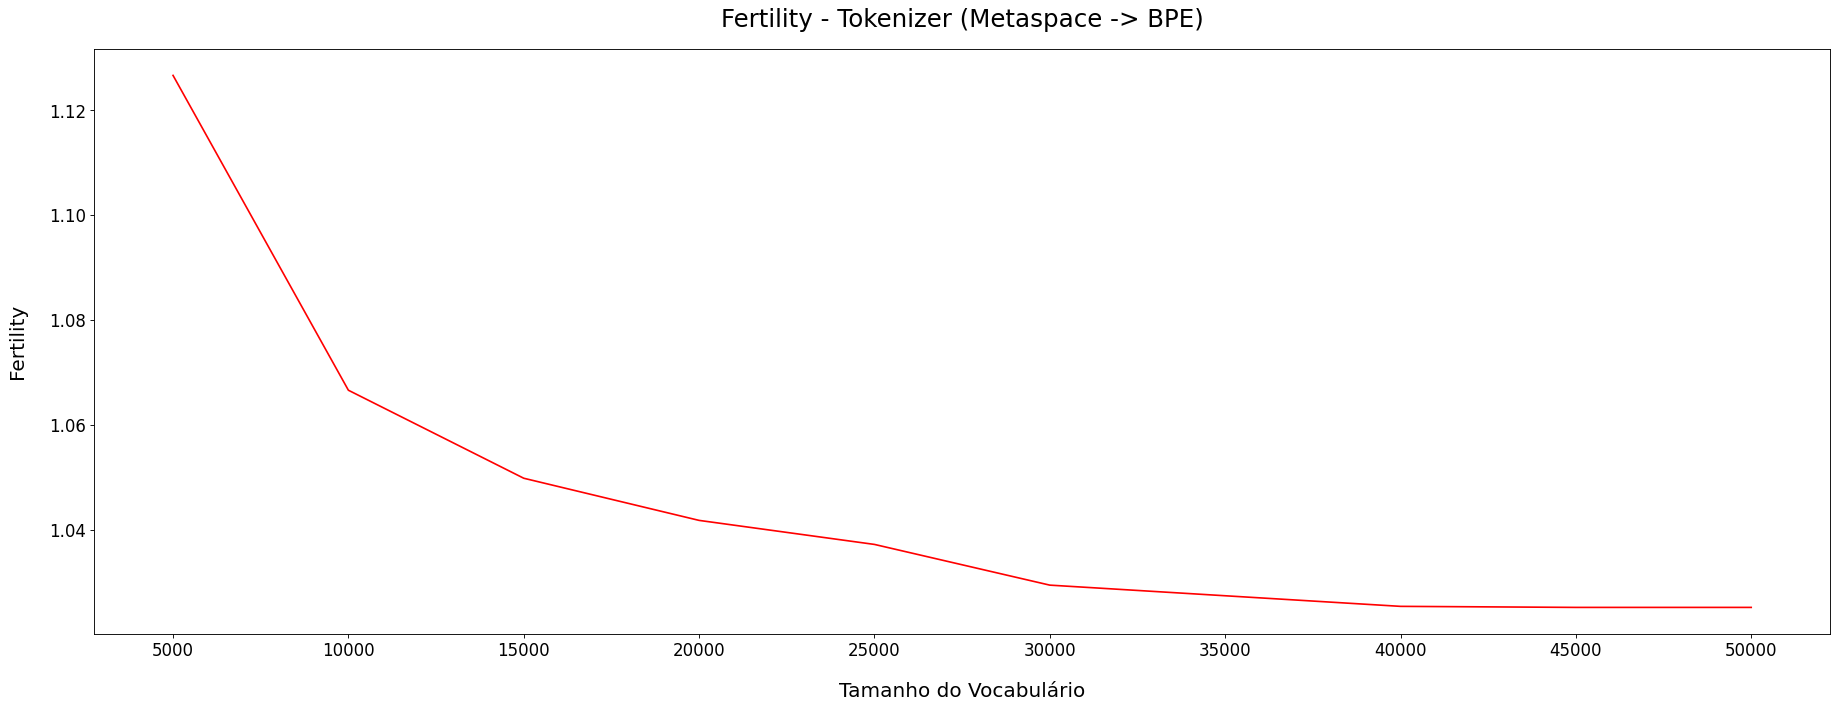


TOKENIZAÇÃO DOS DIFERENTES TOKENIZERS METASPACE -> BPE

One day, a boy named Tim went to the park to play. He saw his friend, Sam, playing with a toy car.

(Metaspace -> BPE, 5000) -> ['▁One', '▁day,', '▁a', '▁boy', '▁named', '▁Tim', '▁went', '▁to', '▁the', '▁park', '▁to', '▁play.', '▁He', '▁saw', '▁his', '▁friend,', '▁Sam,', '▁playing', '▁with', '▁a', '▁toy', '▁car.']
(Metaspace -> BPE, 10000) -> ['▁One', '▁day,', '▁a', '▁boy', '▁named', '▁Tim', '▁went', '▁to', '▁the', '▁park', '▁to', '▁play.', '▁He', '▁saw', '▁his', '▁friend,', '▁Sam,', '▁playing', '▁with', '▁a', '▁toy', '▁car.']
(Metaspace -> BPE, 15000) -> ['▁One', '▁day,', '▁a', '▁boy', '▁named', '▁Tim', '▁went', '▁to', '▁the', '▁park', '▁to', '▁play.', '▁He', '▁saw', '▁his', '▁friend,', '▁Sam,', '▁playing', '▁with', '▁a', '▁toy', '▁car.']
(Metaspace -> BPE, 20000) -> ['▁One', '▁day,', '▁a', '▁boy', '▁named', '▁Tim', '▁went', '▁to', '▁the', '▁park', '▁to', '▁play.', '▁He', '▁saw', '▁his', '▁friend,', '▁Sam,', '▁playing', '▁with',

In [18]:
t

##### **Punctuation -> BPE**

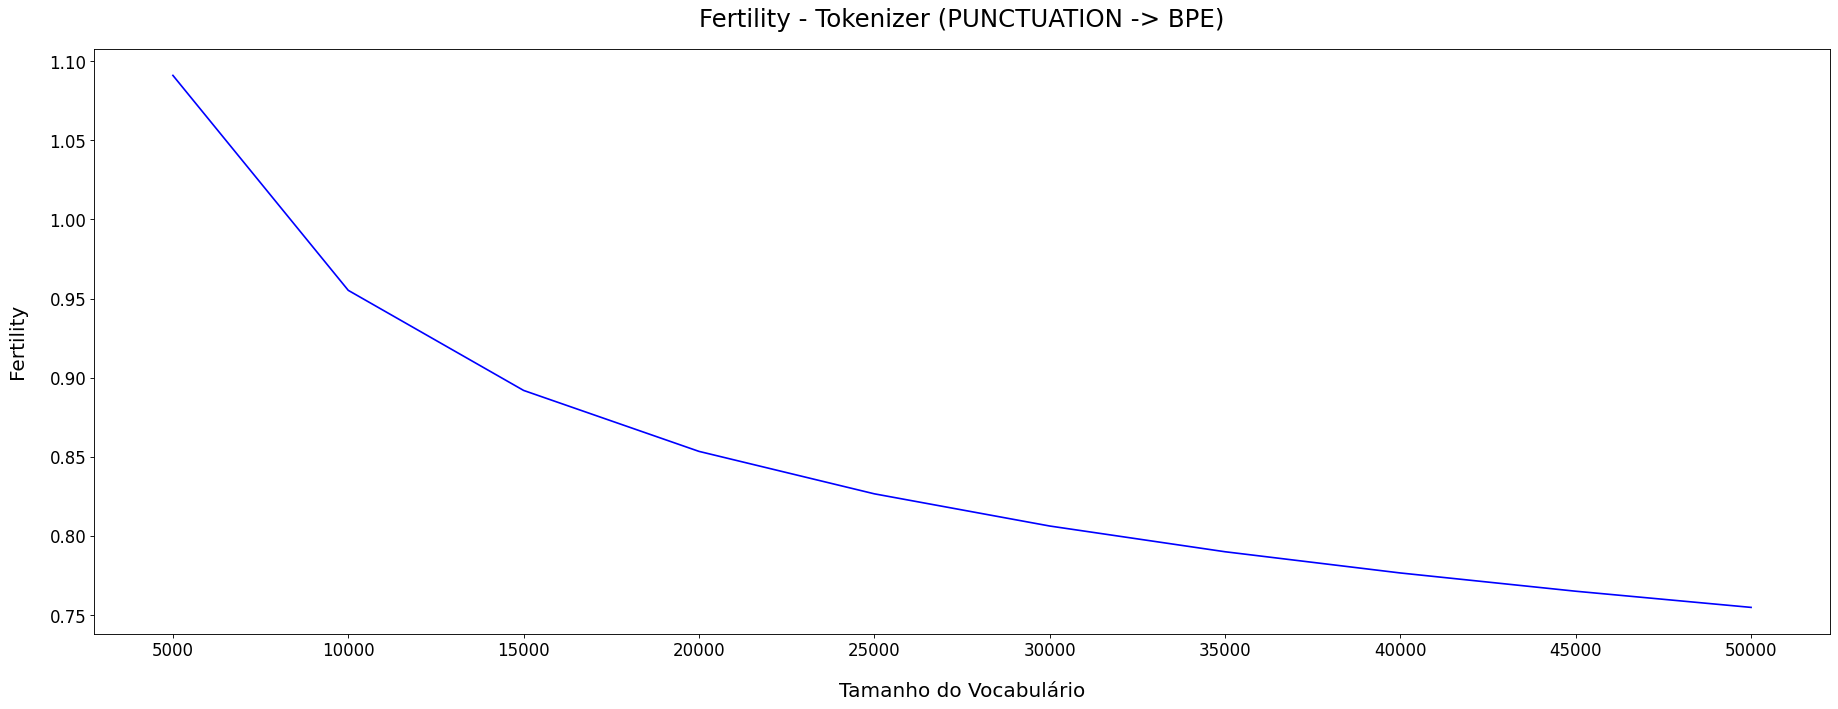


TOKENIZAÇÃO DOS DIFERENTES TOKENIZERS PUNCTUATION -> BPE

One day, a boy named Tim went to the park to play. He saw his friend, Sam, playing with a toy car.

(Punctuation -> BPE, 5000) -> ['One day', ',', ' a boy named Tim', ' went to the park', ' to play', '.', ' He saw', ' his friend', ',', ' Sam', ',', ' playing ', 'with a ', 'toy car', '.']
(Punctuation -> BPE, 10000) -> ['One day', ',', ' a boy named Tim', ' went to the park to play', '.', ' He saw his friend', ',', ' Sam', ',', ' playing ', 'with a ', 'toy car', '.']
(Punctuation -> BPE, 15000) -> ['One day', ',', ' a boy named Tim', ' went to the park to play', '.', ' He saw his friend', ',', ' Sam', ',', ' playing ', 'with a ', 'toy car', '.']
(Punctuation -> BPE, 20000) -> ['One day', ',', ' a boy named Tim', ' went to the park to play', '.', ' He saw his friend', ',', ' Sam', ',', ' playing ', 'with a ', 'toy car', '.']
(Punctuation -> BPE, 25000) -> ['One day', ',', ' a boy named Tim', ' went to the park to play', '.', ' He

In [19]:
t

##### **Whitespace -> BPE**

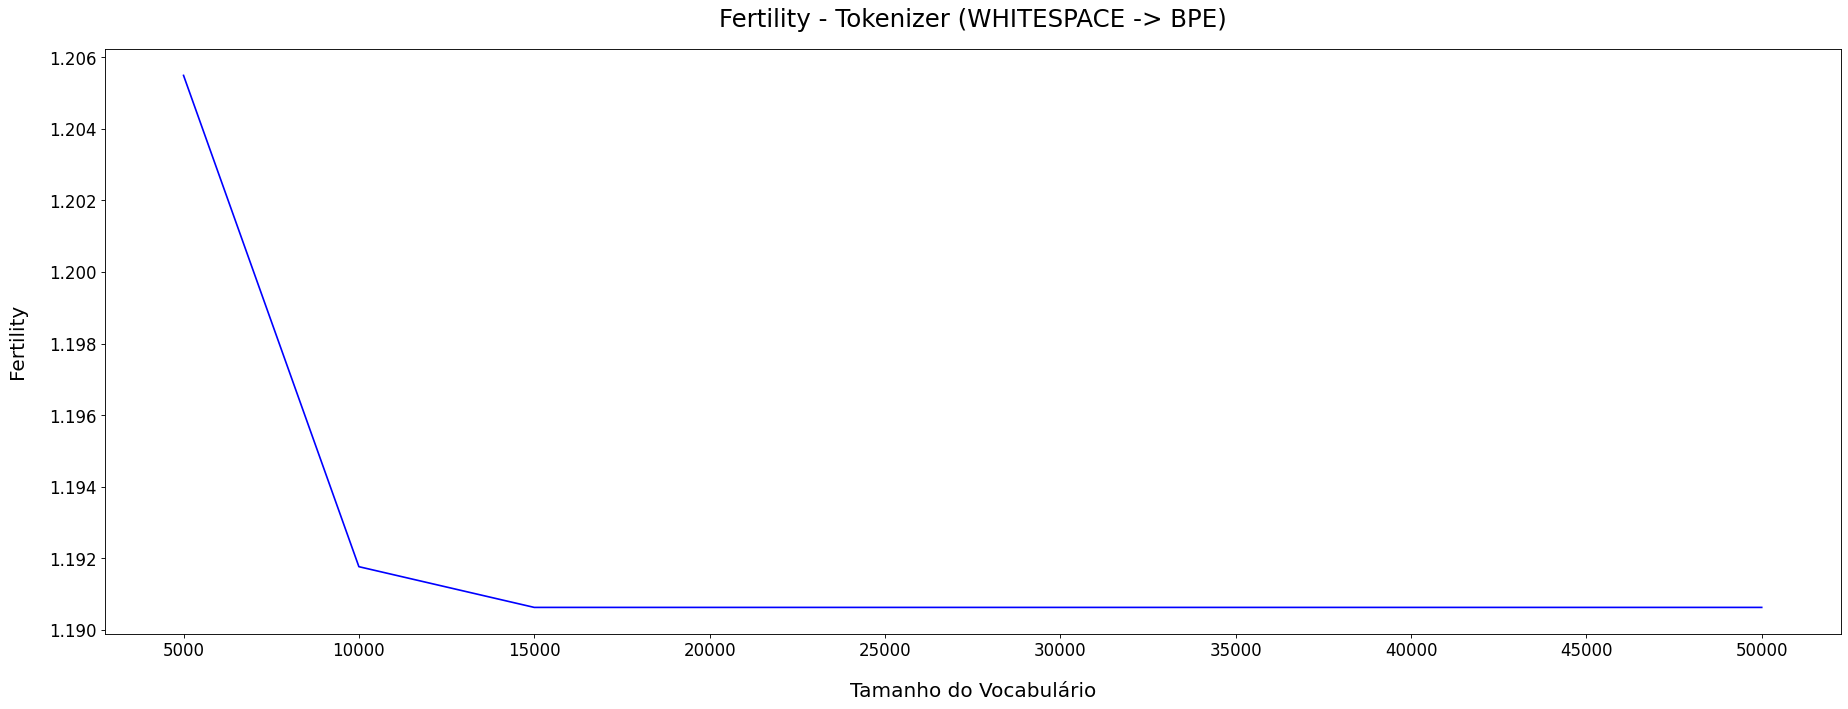


TOKENIZAÇÃO DOS DIFERENTES TOKENIZERS WHITESPACE -> BPE

One day, a boy named Tim went to the park to play. He saw his friend, Sam, playing with a toy car.

(Whitespace -> BPE, 5000) -> ['One', 'day', ',', 'a', 'boy', 'named', 'Tim', 'went', 'to', 'the', 'park', 'to', 'play', '.', 'He', 'saw', 'his', 'friend', ',', 'Sam', ',', 'playing', 'with', 'a', 'toy', 'car', '.']
(Whitespace -> BPE, 10000) -> ['One', 'day', ',', 'a', 'boy', 'named', 'Tim', 'went', 'to', 'the', 'park', 'to', 'play', '.', 'He', 'saw', 'his', 'friend', ',', 'Sam', ',', 'playing', 'with', 'a', 'toy', 'car', '.']
(Whitespace -> BPE, 15000) -> ['One', 'day', ',', 'a', 'boy', 'named', 'Tim', 'went', 'to', 'the', 'park', 'to', 'play', '.', 'He', 'saw', 'his', 'friend', ',', 'Sam', ',', 'playing', 'with', 'a', 'toy', 'car', '.']
(Whitespace -> BPE, 20000) -> ['One', 'day', ',', 'a', 'boy', 'named', 'Tim', 'went', 'to', 'the', 'park', 'to', 'play', '.', 'He', 'saw', 'his', 'friend', ',', 'Sam', ',', 'playing', 'with', 'a'

In [20]:
t

##### **WhitespaceSplit -> BPE**

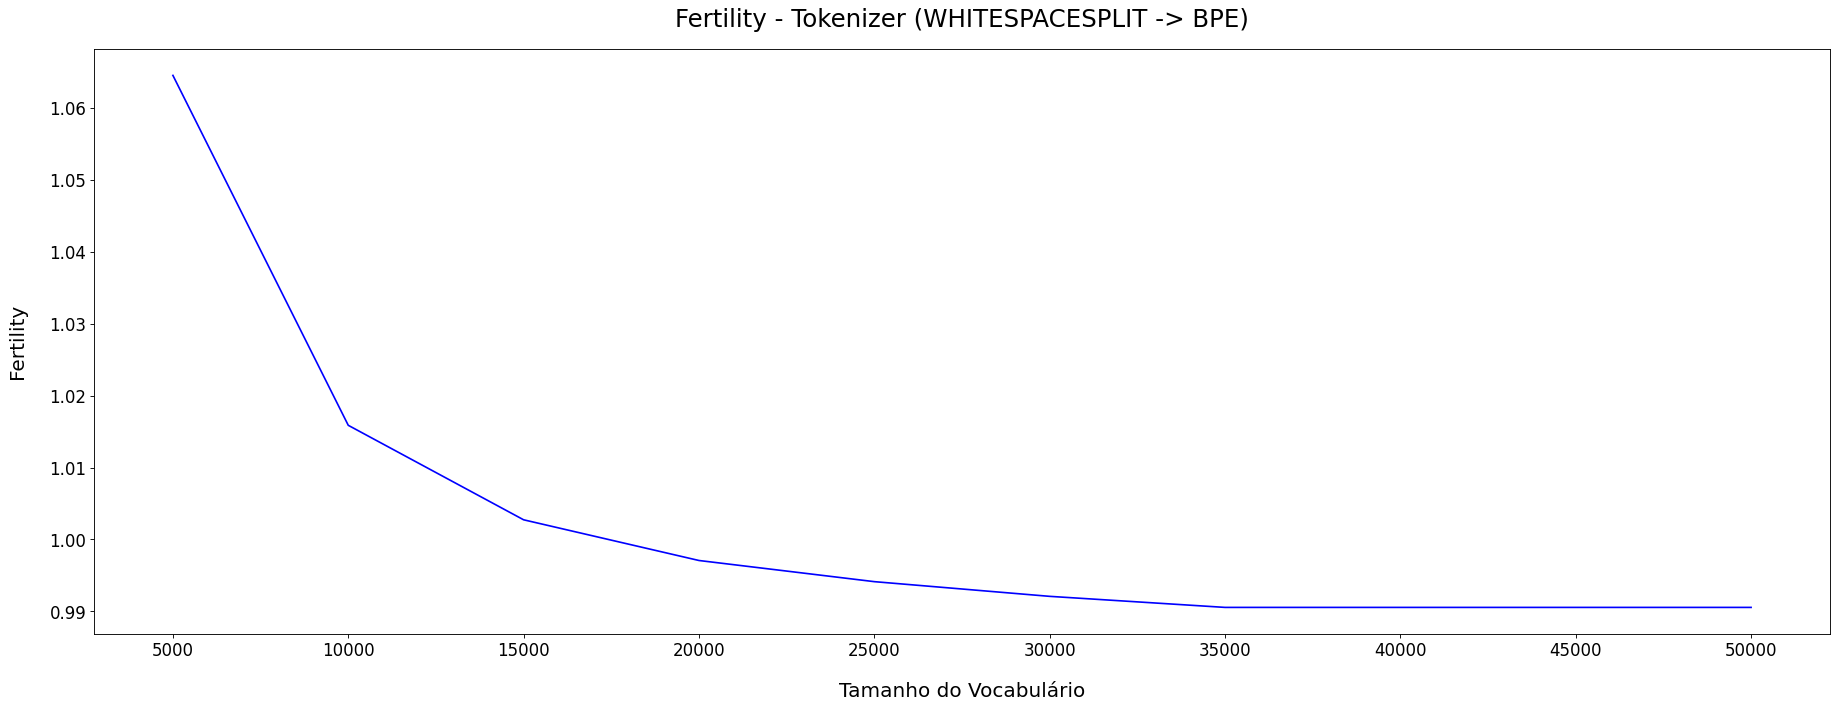


TOKENIZAÇÃO DOS DIFERENTES TOKENIZERS WHITESPACESPLIT -> BPE

One day, a boy named Tim went to the park to play. He saw his friend, Sam, playing with a toy car.

(WhitespaceSplit -> BPE, 5000) -> ['One', 'day,', 'a', 'boy', 'named', 'Tim', 'went', 'to', 'the', 'park', 'to', 'play.', 'He', 'saw', 'his', 'friend,', 'Sam,', 'playing', 'with', 'a', 'toy', 'car.']
(WhitespaceSplit -> BPE, 10000) -> ['One', 'day,', 'a', 'boy', 'named', 'Tim', 'went', 'to', 'the', 'park', 'to', 'play.', 'He', 'saw', 'his', 'friend,', 'Sam,', 'playing', 'with', 'a', 'toy', 'car.']
(WhitespaceSplit -> BPE, 15000) -> ['One', 'day,', 'a', 'boy', 'named', 'Tim', 'went', 'to', 'the', 'park', 'to', 'play.', 'He', 'saw', 'his', 'friend,', 'Sam,', 'playing', 'with', 'a', 'toy', 'car.']
(WhitespaceSplit -> BPE, 20000) -> ['One', 'day,', 'a', 'boy', 'named', 'Tim', 'went', 'to', 'the', 'park', 'to', 'play.', 'He', 'saw', 'his', 'friend,', 'Sam,', 'playing', 'with', 'a', 'toy', 'car.']
(WhitespaceSplit -> BPE, 25000) ->

In [10]:
t

#### **Tokenizer Vencedor**



In [16]:
modelo = Tokenizer(BPE())

trainer = BpeTrainer (vocab_size = 8000)

modelo.pre_tokenizer = Metaspace()
modelo.train (["Dataset Tiny Stories.txt"], trainer)
modelo.save("Tiny-GPT Tokenizer")

tokenizer = Tokenizer.from_file ("Tiny-GPT Tokenizer")

dataset = tokenizer.encode(dataset)

#### **Visualização do Melhor Tokenizer**



*   **Tokens** -> unidades fundamentais de texto que representam <i> palavras</i>, <i>partes de palavras</i> ou <i>caracteres</i>.
*   **Ids** -> representação numérica dos tokens



In [17]:
print (f"Estatísticas do Tokenizer --> {dataset}")
print (f"50 Primeiros Tokens --> {dataset.tokens[0:50]}")
print (f"50 Primeiros Ids --> {dataset.ids[0:50]}")

Estatísticas do Tokenizer --> Encoding(num_tokens=2643056, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])
50 Primeiros Tokens --> ['▁Once', '▁upon', '▁a', '▁time,', '▁there', '▁was', '▁a', '▁reliable', '▁otter', '▁named', '▁Ollie.', '▁He', '▁lived', '▁in', '▁a', '▁river', '▁with', '▁his', '▁family.', '▁They', '▁all', '▁loved', '▁to', '▁play', '▁and', '▁swim', '▁together.\n', 'O', 'ne', '▁day,', '▁Ollie', "'s", '▁mom', '▁said,', '▁"O', 'll', 'ie,', '▁hurry', '▁and', '▁get', '▁some', '▁fish', '▁for', '▁dinner', '!"', '▁Ollie', '▁swam', '▁fast', '▁to', '▁catch']
50 Primeiros Ids --> [256, 261, 80, 263, 230, 105, 80, 3548, 4070, 233, 7355, 136, 468, 138, 80, 1671, 151, 166, 1603, 129, 258, 335, 87, 146, 88, 1290, 803, 38, 1877, 203, 2716, 206, 217, 196, 673, 115, 3477, 5331, 88, 480, 438, 655, 214, 2982, 282, 2716, 1443, 572, 87, 983]


#### **Codificador e Descodificador de um Tokenizer**


In [19]:
teste = tokenizer.encode ("Just do it!")

print ("Codificador:")
print (teste.tokens)
print (teste.ids, "\n")

print ("Descodificador:")
print (tokenizer.decode(teste.ids))

Codificador:
['▁Just', '▁do', '▁it!']
[1370, 201, 2474] 

Descodificador:
▁Just ▁do ▁it!


#### **Espaço Dimensional de um Tokenizer**


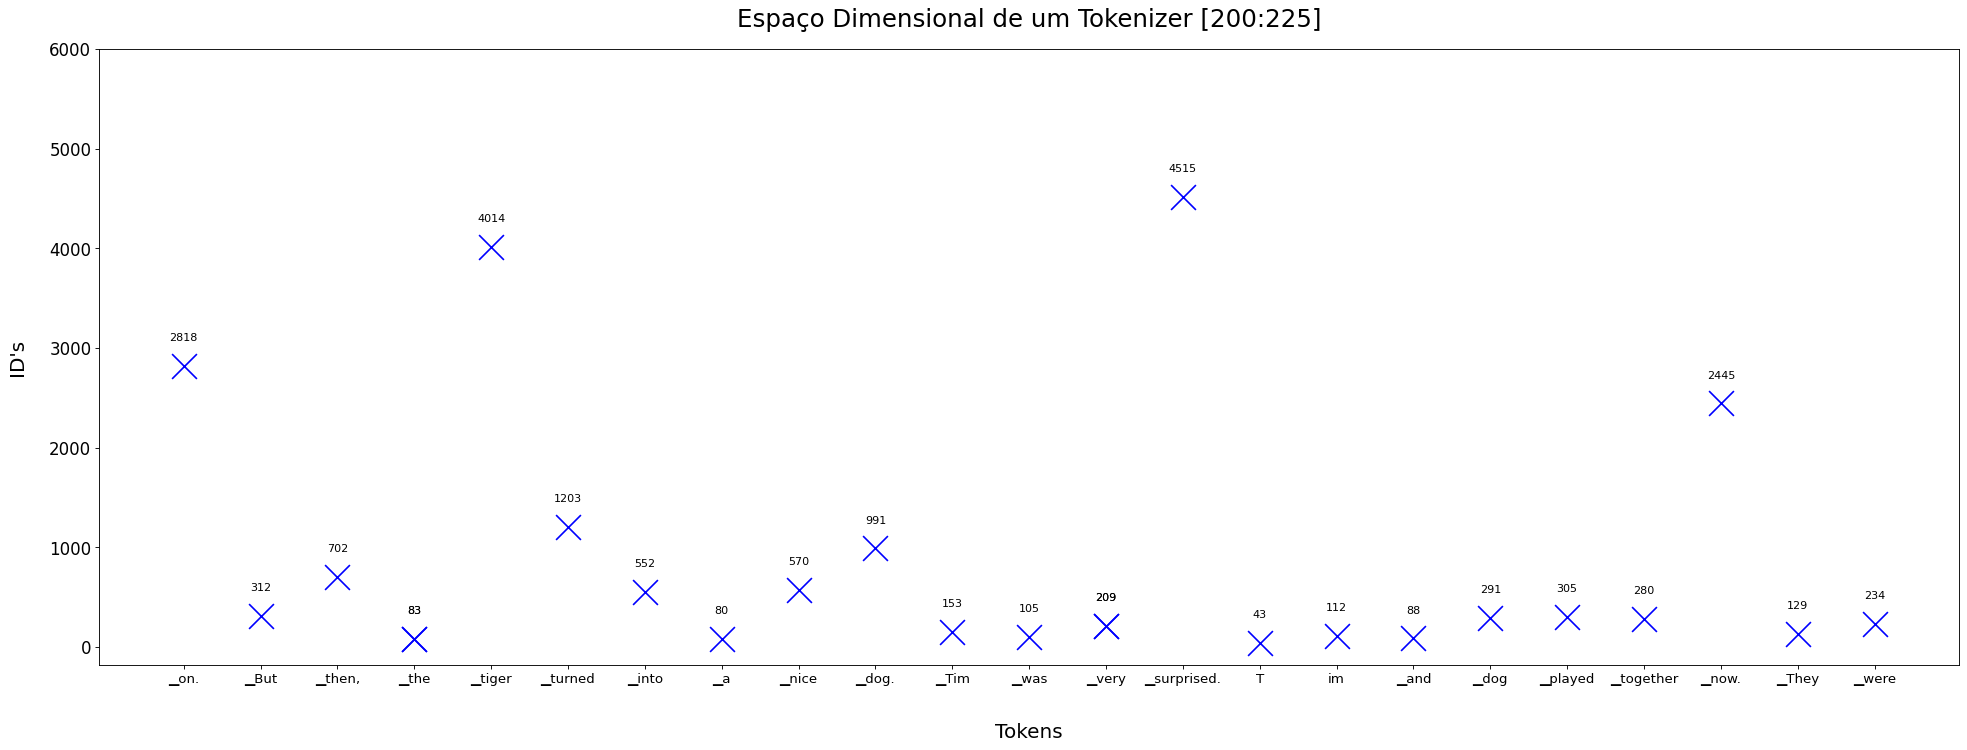

In [24]:
import matplotlib.pyplot as plt

x = dataset.tokens[200:225]
y = dataset.ids[200:225]

plt.figure (figsize = (30, 10), dpi = 80)
plt.scatter (x, y, marker = "x", color = 'blue', s = 500)


for i in range (len(y)):

    plt.text(x[i], y[i] + 250, y[i], ha = "center", size = 10)

plt.xticks (size = 12)
plt.xlabel ("Tokens", size = 18, labelpad = 20)

plt.yticks (list(range(0, 7000, 1000)), size = 15)
plt.ylabel ("ID's", size = 18, labelpad = 20)

plt.title ("Espaço Dimensional de um Tokenizer [200:225]", size = 22, pad = 20)
plt.show()



###


---





### **2. Tensor Shape**

Após a Tokenização, o dataset já se encontra convertido para uma representação numérica. <br>
A organização dos dados de entrada é feita através da definição de dois parâmetros fundamentais: <br>


1.   **Batch Size** - número de sequências processadas em paralelo durante o treino.
2.   **Sequence Length** - número de tokens considerados em cada sequência.


Esta abordagem é necessária porque os Transformers não processam todo o texto de uma vez, mas sim em blocos de tamanho fixo. <br>
De forma análoga à leitura humana, não é possível analisar um texto completo simultaneamente, é necessário dividi-lo em partes para conseguir identificar padrões e relações.

<b> Assim, os dados são representados sob a forma de um tensor com dimensão (B, T). </b>



In [25]:
import torch #https://docs.pytorch.org/docs/stable/index.html
import torch.nn as nn #https://docs.pytorch.org/docs/stable/nn.html
import torch.nn.functional as F #https://docs.pytorch.org/docs/stable/nn.functional.html#torch-nn-functional

#### **Definição do Tensor e Dados de Treino vs Dados de Teste**

In [26]:
tensor = torch.tensor (dataset.ids, dtype = torch.long)
print (len(tensor))
print (tensor [:100])

#Divisão de Dados de Treino e Dados de Teste
n = int (0.9 * len(tensor))
dados_treino = tensor [:n] #90% dos dados
dados_teste = tensor [n:] #10% dos dados


2643056
tensor([ 256,  261,   80,  263,  230,  105,   80, 3548, 4070,  233, 7355,  136,
         468,  138,   80, 1671,  151,  166, 1603,  129,  258,  335,   87,  146,
          88, 1290,  803,   38, 1877,  203, 2716,  206,  217,  196,  673,  115,
        3477, 5331,   88,  480,  438,  655,  214, 2982,  282, 2716, 1443,  572,
          87,  983, 1825,  136,  211,  166,  590,   83, 3894, 1243, 2716,  282,
         148,   83, 3894, 1243, 1069,  282,  148, 7355,  328,  619,   87, 5331,
          88,  983,  655,  214,  460, 1603,  225,   46,   58,  436, 2716,  105,
        6716, 3914,  107,  339,   80,  175,  859, 4412,  136, 1676, 1549,  251,
         192,   80, 3914,  238])


#### **Tensor (B, T)**

In [27]:
Batch_Size = 4
Sequence_Length = 8
torch.manual_seed (1000)

posição = torch.randint (0, len (dados_treino) - Sequence_Length, (Batch_Size, ))
x = torch.stack ([dados_treino [i:i + Sequence_Length] for i in posição])
y = torch.stack ([dados_treino [i + 1: i + Sequence_Length + 1] for i in posição])

print (x.shape) #(B, T)
print (x)
print (y.shape) #(B, T)
print (y)

#mais para a frente
sda = x

torch.Size([4, 8])
tensor([[5383,  161,  237,   87,  357,   83, 4521, 4344],
        [2611,   42,  621,   88,  221,  425,   87,   83],
        [ 133,  105, 1207,   88, 3633,  153,   88,  981],
        [ 162, 2043,   83, 1314,  288, 6743,  685,  217]])
torch.Size([4, 8])
tensor([[ 161,  237,   87,  357,   83, 4521, 4344,   35],
        [  42,  621,   88,  221,  425,   87,   83,  879],
        [ 105, 1207,   88, 3633,  153,   88,  981,  487],
        [2043,   83, 1314,  288, 6743,  685,  217,  196]])


###


---



### <b> 3. Embedding </b>

Word Embeddings são representações vetoriais de palavras.

Normalmente, cada token é mapeado para um <b> vetor de valores reais</b>, onde a sua posição no espaço vetorial reflete o seu significado. Palavras com significados semelhantes tendem a estar próximas nesse espaço, permitindo ao modelo capturar relações semânticas entre elas.

Neste ponto, introduz-se uma das variáveis fundamentais de uma arquitetura Transformer:


1.   <b> Embedding Dimension </b> - Define a dimensão dos vetores utilizados para representar cada token e é um dos principais fatores no número total de parâmetros do modelo.

Os Embeddings são parâmetros treináveis, ou seja, são ajustados durante o treino do modelo de forma a melhorar a representação dos tokens no espaço vetorial.

<b> Após a aplicação dos Embeddings passamos a ter um tensor com dimensão (B, T, C). </b>

In [28]:
Embedding_Dimension = 16

Embedding = nn.Embedding (tokenizer.get_vocab_size(), Embedding_Dimension) #Porquê vocab_size ? Vocab_Size dá-nos o número dos tokens únicos que existem.
#Se usássemos por exemplo len(Tokenizer.tokens) não era correto porque estariamos a criar um vetor para tokens repetidos.
x_embedding = Embedding (x)
print (x_embedding.shape) #(B,T,C)
print (f"O Token {x[0,1]} agora é representado pelo vetor:")
print (x_embedding[0,1]) #Representação vetorial do primeiro token após embedding

torch.Size([4, 8, 16])
O Token 161 agora é representado pelo vetor:
tensor([ 1.7774,  0.1469, -0.3023, -0.5046, -2.0486, -0.8960,  0.8245,  0.9241,
        -0.3788,  1.7110,  0.8152,  0.2453, -1.2243, -0.1304, -0.2232, -0.2848],
       grad_fn=<SelectBackward0>)


#### **Representação dos Tokens e dos seus respetivos Embeddings**
Cada token passa a ser representado por um vetor.

Esta tabela também é excelente para perceber o que <b> nn.Embedding </b> faz por trás.

In [29]:
import pandas as pd

dados = []

for i in range (8):
  dados.append ({
      "Token": sda[0,i],
      "Pós Embedding -> Sequence Length [0]": x_embedding[0,i].detach().cpu().numpy()
  })

df = pd.DataFrame (dados)
print(df.to_string()) #Melhor maneira de mostrar a tabela completa

          Token                                                                                                                                                              Pós Embedding -> Sequence Length [0]
0  tensor(5383)   [-0.6550031, -0.8898855, 0.719709, -1.053178, -0.38683298, -1.0807195, 1.4434127, -0.41286376, 1.5832657, -0.31687176, -0.49571645, -0.76567215, -0.7344404, -0.6002092, 1.4740021, -2.0729089]
1   tensor(161)    [1.7774044, 0.14689994, -0.3023286, -0.5046191, -2.0486012, -0.8960302, 0.8245418, 0.9241395, -0.3788303, 1.7110344, 0.81515366, 0.24526072, -1.2243475, -0.13037585, -0.22323291, -0.2848408]
2   tensor(237)    [0.44727445, -1.0874941, 0.3502634, 1.3777605, 1.0956962, -1.7334023, 0.3823119, 0.88006395, 0.066850804, -0.5890923, 0.82223034, -0.2516813, -1.3240955, -0.9793675, -0.5220944, -0.67033446]
3    tensor(87)    [-0.19269624, -0.14614296, 1.4900721, 0.6922106, -0.14438213, -0.09354565, 0.698145, -0.13919245, 1.4728165, 0.2849766, -1.1447818, 0.8410632

###


---


### **4. Positional Encoding**

<b>Positional Encoding</b> é uma técnica que adiciona informação sobre a posição de cada token na sequência.

Isto é necessário porque os Transformers, por si só, não processam os tokens de forma sequencial (como as RNNs) e, por isso, não têm noção da ordem das palavras.

Ao introduzir esta informação, o modelo consegue distinguir entre a posição relativa ou absoluta dos tokens, o que é essencial para compreender a estrutura de uma frase e o significado do texto.

A intuição é a seguinte:

* “Rei ama rainha” ≠ “Rainha ama rei” — <b>a ordem importa</b>!

No paper original são utilizados encodings fixos. <br>
No entanto, em muitas implementações modernas, são utilizados positional encodings treináveis, que permitem ao modelo aprender a melhor representação para cada posição durante o treino.

**Neste projeto foram utilizados encodings treináveis.**

In [30]:
Positional_Embedding = nn.Embedding (Sequence_Length, Embedding_Dimension) #Positinal Encoding não é nada mais do que um Embedding
Positional_Encoding = Positional_Embedding (torch.arange (Sequence_Length))
print (Positional_Encoding.shape)

torch.Size([8, 16])


###


---


### **5. Embedding + Positional Encoding**

Neste último passo, antes de introduzirmos o mecanismo <b> Attention</b>, é necessário combinar os Embeddings dos tokens com os Positional Encodings.

Esta combinação é feita através de uma soma elemento a elemento, permitindo que cada token transporte simultaneamente informação sobre o seu significado e a sua posição na sequência.

Este passo é fundamental, pois prepara a representação final que será utilizada pelo mecanismo <b> Attention<b>. <br>
Por essa razão, neste Notebook é apresentado como uma etapa separada e de especial importância no fluxo da arquitetura.

In [31]:
x = x_embedding + Positional_Encoding #Dados que vão entrar no modelo
print (x.shape)
print (x[:100])

torch.Size([4, 8, 16])
tensor([[[-2.1326e+00, -1.0274e+00,  1.5609e+00, -1.3532e+00, -6.4613e-01,
          -2.1623e+00,  1.2984e+00,  1.2696e+00,  3.0684e+00,  1.0949e+00,
           4.8051e-01, -1.5865e+00, -8.7087e-02, -7.8197e-01,  1.5644e+00,
          -2.4721e+00],
         [ 3.1207e-01,  7.1251e-02, -1.2280e-01, -4.8031e-01, -2.0078e+00,
          -4.0288e-01,  4.6945e-01,  6.5149e-01, -2.8597e-01,  1.5956e+00,
           1.5549e+00,  1.9964e+00, -8.2652e-01,  1.1572e+00, -7.6222e-02,
          -4.6052e-01],
         [-3.2266e-01, -1.5174e+00,  6.4158e-01,  2.0078e+00, -8.5215e-01,
          -1.8710e+00,  4.9936e-01,  7.5644e-01, -4.8657e-01, -1.1196e+00,
           1.8901e+00, -4.3882e-01, -3.1574e+00, -3.6943e-01, -1.9513e+00,
          -6.8812e-02],
         [ 1.7984e+00,  2.5114e-01,  2.0240e+00,  1.3411e+00, -3.1011e-01,
          -1.7915e+00, -3.2437e-01,  1.0267e+00,  7.2454e-01,  1.3891e-01,
          -1.2043e+00,  1.0478e-01,  1.5734e-01,  9.8470e-01,  1.8007e+00,
     

##### **Embedding + Positional Encoding**

In [32]:
dados = []

for i in range (8):
  dados.append ({
      "Token": sda[0,i],
      "Embedding + Positional Encoding -> Sequence Length [0]": x[0,i].detach().cpu().numpy()
  })

df = pd.DataFrame (dados)
print(df.to_string()) #Melhor maneira de mostrar a tabela completa

          Token                                                                                                                                             Embedding + Positional Encoding -> Sequence Length [0]
0  tensor(5383)           [-2.1326299, -1.027403, 1.5609097, -1.3531505, -0.6461277, -2.1622794, 1.298405, 1.2695975, 3.06841, 1.0948933, 0.48051322, -1.5864604, -0.08708674, -0.78197026, 1.5643662, -2.4721394]
1   tensor(161)    [0.31206906, 0.071251065, -0.122799724, -0.4803076, -2.0078197, -0.40287986, 0.46944943, 0.6514897, -0.28596658, 1.5956165, 1.5549285, 1.9964164, -0.826517, 1.157212, -0.0762216, -0.46051726]
2   tensor(237)   [-0.32266152, -1.5173856, 0.641582, 2.007805, -0.85215175, -1.8709887, 0.49936032, 0.75643724, -0.48657063, -1.1196268, 1.8901185, -0.4388229, -3.1574173, -0.36943406, -1.9512589, -0.06881225]
3    tensor(87)          [1.7984438, 0.25113615, 2.0239809, 1.3411398, -0.3101055, -1.7914903, -0.3243733, 1.0266868, 0.72454333, 0.13890548, -1.204341, 0.1

###


---

### **6. [Attention](https://medium.com/@nitinmittapally/understanding-attention-in-transformers-a-visual-guide-df416bfe495a)**

<b> Attention </b> é um mecanismo que permite ao modelo focar-se em diferentes partes da sequência de entrada ao processar cada token.

De forma análoga à atenção humana, ao ler uma frase não analisamos cada palavra isoladamente, em vez disso, consideramos o contexto relevante para compreender o significado. <br>
Da mesma forma, o mecanismo <b> Attention </b> permite ao modelo atribuir diferentes níveis de importância aos vários tokens da sequência, capturando relações e dependências entre eles. <br>
Ao contrário das RNNs, este mecanismo permite acesso direto a todos os Tokens anteriores, facilitando a captura de dependências de longo alcance.

Este é o mecanismo central da arquitetura Transformer e pode ser aplicado de diferentes formas, destacando-se três variantes principais:

*   <b> Self-Attention </b> - cada token atende a todos os outros tokens da mesma sequência, permitindo capturar relações internas.
*   <b> Masked Self-Attention </b> - semelhante ao Self-Attention, mas com uma máscara que impede o modelo de “ver o futuro”, sendo essencial para tarefas de geração de texto.
*   <b> Cross-Attention </b> - permite relacionar duas sequências diferentes, onde uma sequência atende à outra


<b> Neste Notebook será utilizada a variante Masked Self-Attention, característica de modelos do tipo GPT. </b>

#### <b> Query, Key e Value (Q, K, V) </b>

<b> Attention </b> baseia-se em três representações vetoriais:

* <b> Query (Q) </b> - O que ando à procura ?
* <b> Key (K) </b> - O que represento ?
* <b> Value (V) </b> - Que informação trago comigo ?

A Attention é calculada através da comparação entre <b> Queries </b> e <b> Keys</b>, permitindo determinar o grau de relevância entre tokens. <br>
Esses pesos são depois aplicados aos <b> Values </b> para produzir a saída final. <br>
<b> Vamos ver em código: </b>

In [33]:
B,T,C = x.shape #Batch, Sequence Length, Embedding_Dimension
#print (x.shape)
Head_Size = C = 16 #Head_Size representa a divisão do vetor #Se tiver um vetor com Emb_Dimension de valor 16, e tiver uma arquitetura Multi-Head Attention com 2 Heads, a minha Head_Size é 8. #Isto significa que por cada Head eu vou dar 8 valores do meu vetor de Embeddings

#C = Embedding_Dimension #Aplica uma Transformação Linear a partir dos Embeddings #Uma projeção desses Embeddings num espaço
Query = nn.Linear (C, Head_Size, bias = False)
Key = nn.Linear (C, Head_Size, bias = False)
Value = nn.Linear (C, Head_Size, bias = False)

#Aplico a projeção nos dados
Q = Query (x) #Y = X * Wq
K = Key (x) #Y = X * Wk
V = Value (x) #Y = X * Wv

print (x.shape)
print (Q.shape)
print (K.shape)
print (V.shape)

torch.Size([4, 8, 16])
torch.Size([4, 8, 16])
torch.Size([4, 8, 16])
torch.Size([4, 8, 16])


#### **Heatmap da Representação Vetorial do Embedding e dos respetivos Q, K e V**

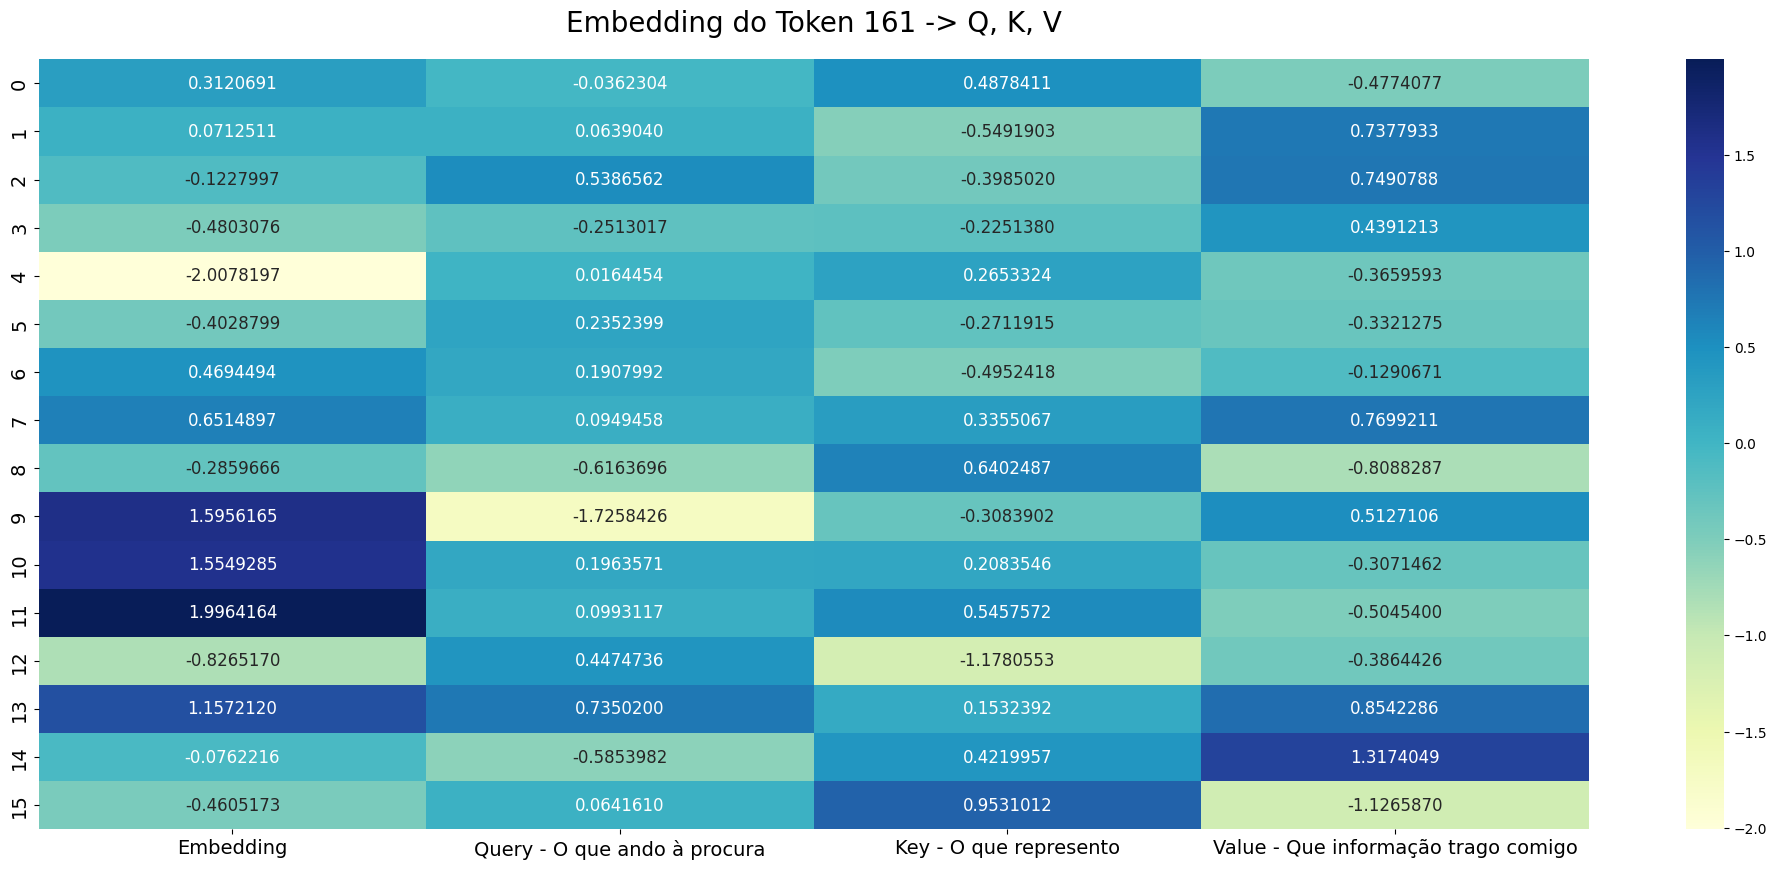

In [34]:
import seaborn as sns

df = pd.DataFrame({
    "Embedding": x [0,1].detach().numpy(), #x[0,1] vai selecionar um tensor da posição 1 da linha 0 do tensor
    "Query - O que ando à procura": Q [0,1].detach().numpy(),
    "Key - O que represento": K [0,1].detach().numpy(),
    "Value - Que informação trago comigo": V [0,1].detach().numpy(),
})

plt.figure (figsize = (25, 10))
sns.heatmap(df, cmap = "YlGnBu", annot = True, fmt = ".7f", annot_kws = {"size": 12})

plt.xticks (size = 14)
plt.yticks (size = 14)

plt.title(f"Embedding do Token {sda[0,1]} -> Q, K, V", size = 20, pad = 20)
plt.show()


#### **Representação do Espaço Dimensional do Embedding e dos respetivos Q, K e V**

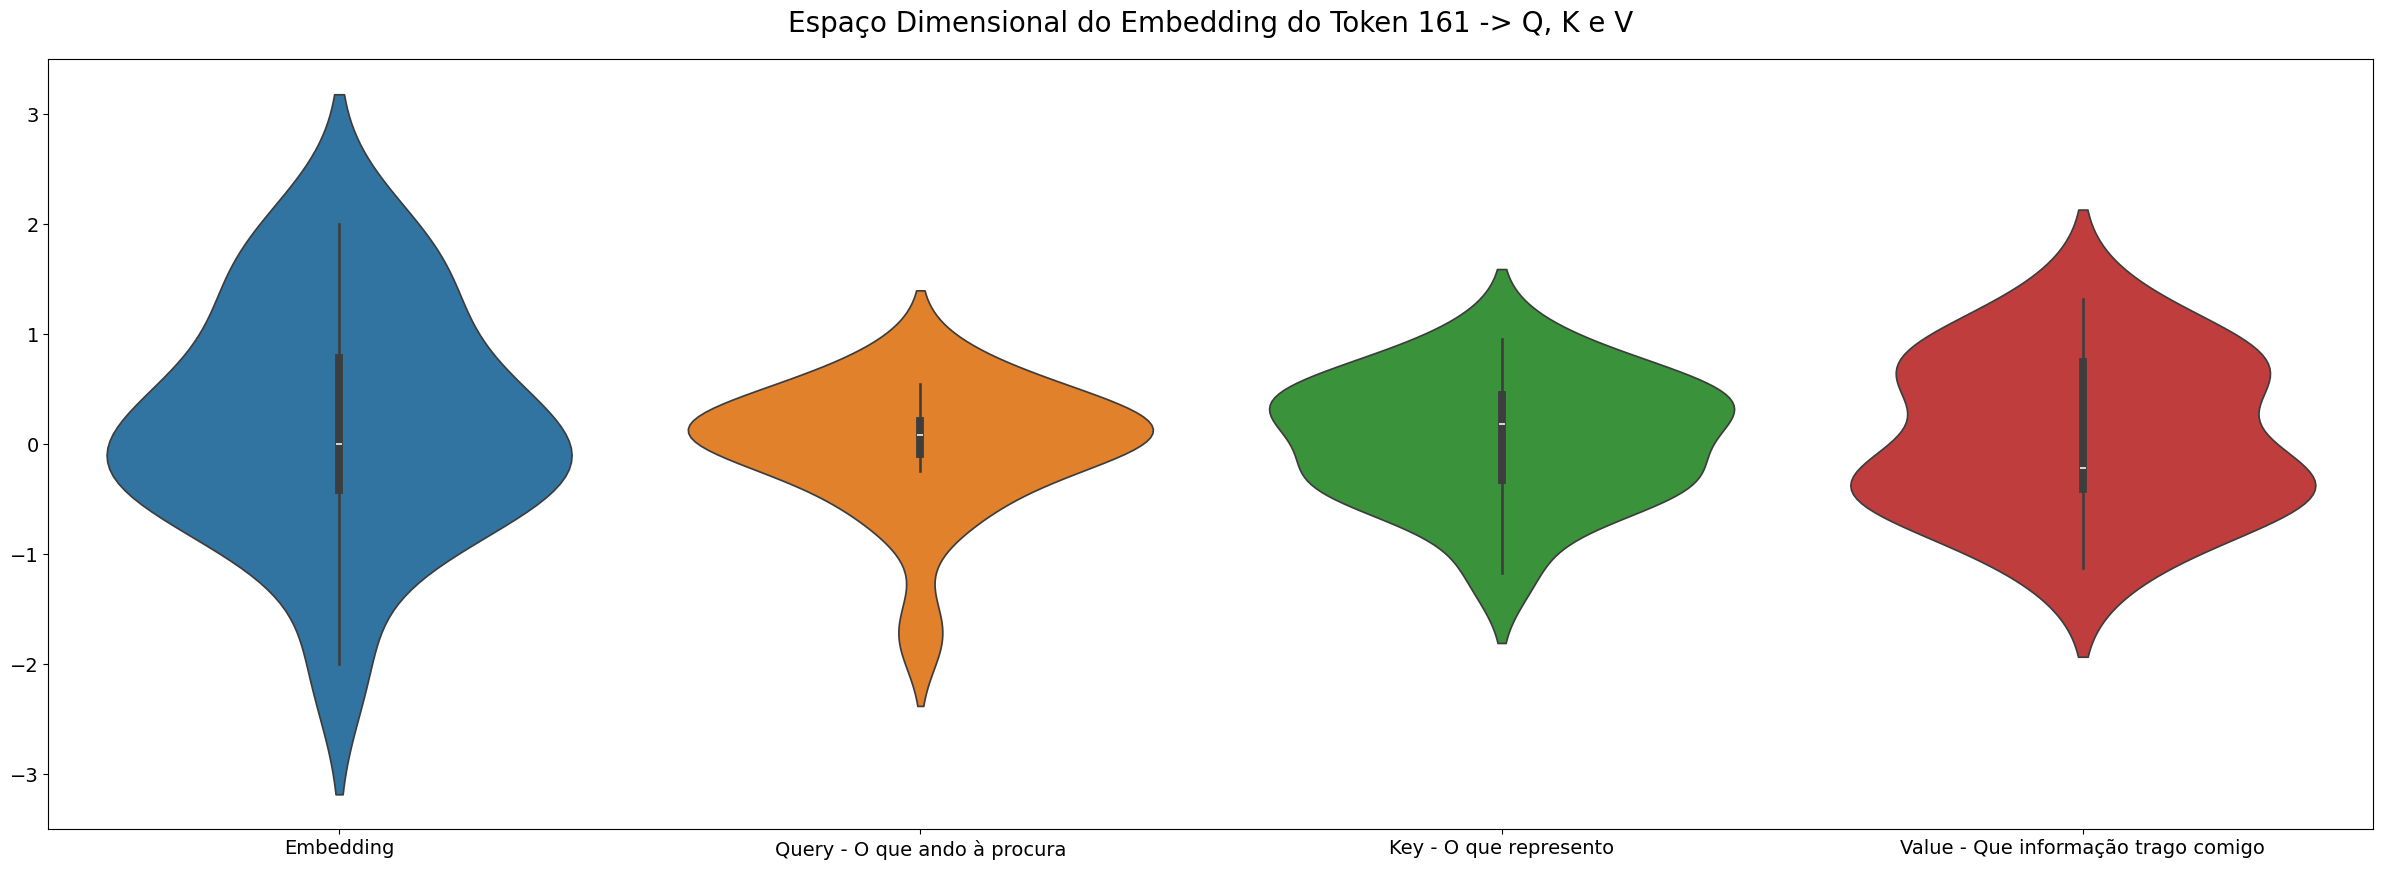

In [35]:
plt.figure (figsize = (30, 10))
sns.violinplot(df, cmap = "YlGnBu")

plt.xticks (size = 14)
plt.yticks (size = 14)

plt.title(f"Espaço Dimensional do Embedding do Token {sda[0,1]} -> Q, K e V", size = 20, pad = 20)
plt.show()

#### **Scaled Dot-Product Attention (Q @ K)**

**Scaled Dot-Product Attention** é o mecanismo central que permite aos tokens "interagir entre si" dentro de um Transformer.

Em vez de tratar cada posição isoladamente, o modelo passa a construir significado com base no contexto global.

É aqui que deixa de haver apenas transformações individuais (Q, K, V) e passa a haver comunicação entre tokens.

Um ponto importante é que este mecanismo é diferenciável e altamente <b> paralelizável </b>, o que o torna eficiente para treino em larga escala. <br>
Além disso, como todos os tokens "conversam" entre si simultaneamente, o modelo consegue capturar dependências de longo alcance — algo que era difícil em arquiteturas anteriores como RNNs.

In [36]:
attention_scores = Q @ K.transpose (-2, -1) * (Head_Size ** -0.5) #(B, T, C) @ (B ,C ,T) --> (B, T, T) #Estamos a fazer com que os tokens falem entre si, troquem a sua informação
print (f"Após os Tokens falarem entre si (Q @ K.t) ->\n{attention_scores.shape}") # (B, T, T) porque são apenas relações entre os tokens
print (attention_scores[0])

tril = torch.tril (torch.ones(T, T)) #Cria uma máscara
attention_scores  = attention_scores.masked_fill (tril == 0, float ('-inf')) #Aplica a máscara na Atenção
print (f"\nAplicação de Mask Attention -> \n {attention_scores[0]} \n")

attention_scores = F.softmax (attention_scores, dim = -1) #Softmax para normalizar #A soma dos valores dá 1
print (f"Aplicação de Softmax para normalizar os valores -> \n {attention_scores[0]}\n")

output = attention_scores @ V #Resultado final mostra as relações entre todos os Tokens de uma Sequence length
print (f"Output (attention_scores @ V) -> \n{output.shape} \n{output[0]}")

Após os Tokens falarem entre si (Q @ K.t) ->
torch.Size([4, 8, 8])
tensor([[ 1.3775,  0.0980,  0.3307,  0.6525,  1.0066,  0.1437,  0.4098,  0.3791],
        [-0.6385, -0.1751, -0.4454, -0.3017, -0.1070, -0.2943,  0.2465,  0.1227],
        [-0.1851, -0.7411, -0.7219,  0.0245, -0.5061, -0.4320, -0.7871,  0.2537],
        [-0.2846,  0.1532, -0.6058, -0.4617, -0.1924, -0.0777,  0.7666, -0.2491],
        [ 0.2679, -0.3239,  0.9224,  0.0678, -0.4869,  0.7739, -1.5838, -0.1054],
        [ 0.6897, -0.3412, -0.3966,  0.7617,  0.9681, -0.0941, -0.2419, -0.1617],
        [ 1.1347,  0.2915,  1.1352,  0.1684,  0.1870,  0.3548,  0.1405,  0.9334],
        [-0.4693, -0.2360, -0.1936,  1.4472, -1.6055, -1.0163, -0.5373, -0.0579]],
       grad_fn=<SelectBackward0>)

Aplicação de Mask Attention -> 
 tensor([[ 1.3775,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf],
        [-0.6385, -0.1751,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf],
        [-0.1851, -0.7411, -0.7219,    -inf,

###


---

### **7. [Add & Norm](https://arxiv.org/pdf/1607.06450)**

<b> Layer Normalization (LayerNorm ou Norm) </b> é uma técnica que estabiliza e acelera o treino de Redes Neurais. <br>
Normaliza as ativações dentro de cada exemplo (ao longo das features), garantindo média próxima de 0 e variância próxima de 1.

Ao fazê-lo, reduz a sensibilidade à escala dos dados e à inicialização dos pesos, tornando o treino mais estável e eficiente. <br>
É especialmente eficaz em <b> RNNs e Transformers </b>, onde ajuda a mitigar problemas de gradientes instáveis e melhora a convergência.

<b> Residual Connection (ou Add) </b> é uma componente simples mas fundamental em arquiteturas profundas.
Consiste em somar a entrada original ao output de uma camada.

Este mecanismo cria um <b> "um atalho" </b> para a informação, permitindo que o modelo preserve o sinal original ao longo das camadas.

Como resultado, facilita o fluxo de gradientes, reduz o problema de <i> vanishing gradients </i> e permite treinar redes muito mais profundas.

In [37]:
LayerNorm = nn.LayerNorm (Embedding_Dimension) #Layer Norm

output = x + LayerNorm (output) #Residual Connection

print ("Output após Add & Norm ->")
print (output.shape)
print (output[0])

Output após Add & Norm ->
torch.Size([4, 8, 16])
tensor([[-0.5878, -0.8905,  3.1845, -0.0544, -1.4245, -2.0113,  1.8692,  1.0057,
          1.2222,  1.0264, -0.9210, -2.0279,  0.8462, -1.2257,  1.7955, -3.7188],
        [ 0.7522,  0.7570,  1.4560,  0.6297, -2.8484, -0.6614,  0.6412,  1.1278,
         -2.1551,  1.9590,  0.3966,  1.2326, -0.6687,  1.6018,  1.1816, -2.2565],
        [ 0.3512, -1.0446,  2.1565,  3.1500, -2.4462, -2.2294,  0.9976,  1.1259,
         -2.1387, -1.0680,  1.0514, -1.3858, -1.9879, -0.1372, -1.1686, -1.5859],
        [ 2.0941,  1.2021,  3.5869,  2.3567, -1.8163, -2.4937, -0.1205,  1.5062,
         -0.9566,  0.1491, -2.0174, -0.7102,  0.6149,  1.7512,  3.0160, -0.2825],
        [ 0.2582,  1.0927,  2.0529, -0.9252, -4.2965, -0.1880,  2.8680,  1.0857,
         -3.6931,  1.0215, -2.6359, -1.7411,  2.5537, -1.9743,  0.7821,  0.2672],
        [ 1.0324, -0.5746,  3.9829,  1.1729,  0.9639,  0.3617, -1.3863,  1.1403,
         -1.1512, -0.2289, -0.9656,  0.8834, -1.7134, -

###


---

### **8. Feed Forward (Multi Layer Perceptron)**

Self Attention permite que os tokens recolham informação contextual ao longo de toda a sequência. Mas a Attention, por si só, é limitada pois é uma operação fundamentalmente linear.

Uma <b> Feedforward Neural Network (FNN ou Multi Layer Perceptron) </b> fornece exatamente este ingrediente em falta.

Tem como principal função aplicar uma <b> transformação não linear </b> à representação de cada token de forma independente. Como se fosse uma camada de <i> «pensamento» </i> do Transformer.

Depois de a Attention ter encaminhado a informação entre posições e montado representações sensíveis ao contexto, a MLP processa cada uma dessas representações através de uma pequena Rede Neural capaz de aprender limites de decisão curvos e de alta dimensão.

<b> É aqui que ocorre o verdadeiro trabalho computacional da compreensão da linguagem. </b>



In [38]:
MLP = nn.Sequential (
    nn.Linear (Embedding_Dimension, 4 * Embedding_Dimension),
    nn.ReLU (),
    nn.Linear (Embedding_Dimension * 4, Embedding_Dimension)
)

output = MLP (output)
print ("Output após Feed Forward ->")
print (output.shape)
print (output[0])

Output após Feed Forward ->
torch.Size([4, 8, 16])
tensor([[ 0.4505,  0.0339,  0.2105,  0.7285,  0.8972, -0.2566,  0.3162, -0.1733,
         -0.3165, -0.0533, -0.3739,  0.1908, -0.0578, -0.2758,  0.4873,  0.2962],
        [ 0.6946,  0.0672, -0.0618,  0.1717,  0.7297, -0.3662, -0.1788, -0.3757,
         -0.6340,  0.6092, -0.6696,  0.0711,  0.4341, -0.3123,  0.4549,  0.5695],
        [ 0.3119,  0.0216, -0.3976, -0.0239,  0.0066, -0.4648,  0.0060, -0.4492,
         -0.0422,  0.1955,  0.0522, -0.2839, -0.0444, -0.1243,  0.2695,  0.3652],
        [ 1.0024, -0.0025,  0.0219,  0.5037,  0.3772, -0.1794, -0.0381,  0.0353,
         -0.9326,  0.5536, -0.3062, -0.0164,  0.1522, -0.3994,  0.8721, -0.3529],
        [ 0.4426,  0.8872, -0.5441,  0.4206,  0.7455,  0.2122,  0.1608, -0.2309,
         -0.2338,  0.7758, -0.5376, -0.0866,  0.7605, -0.1070,  0.4181,  0.3292],
        [ 0.0467,  0.5102, -0.3191,  0.4295,  0.2427, -0.5459,  0.3623, -0.3216,
         -0.6267, -0.3484,  0.1908, -0.3338, -0.3956,

###


---

### **9. Add & Norm (Sim, outra vez)**



In [39]:
LayerNorm = nn.LayerNorm (Embedding_Dimension) #Layer Norm

output = x + LayerNorm (output) #Residual Connection

print ("Output após Add & Norm ->")
print (output.shape)
print (output[0])

Output após Add & Norm ->
torch.Size([4, 8, 16])
tensor([[-1.2698, -1.2912,  1.7746,  0.2615,  1.4249, -3.2118,  1.7979,  0.4452,
          1.8569,  0.5951, -0.8865, -1.4260, -0.5990, -1.8836,  2.5266, -2.0268],
        [ 1.6731,  0.0536, -0.4238, -0.2684, -0.5696, -1.3728, -0.0888, -0.3393,
         -1.8445,  2.7690, -0.0818,  1.9874, -0.0380,  0.3056,  0.7582,  0.6257],
        [ 1.0764, -1.2802, -0.7995,  2.0627, -0.6752, -3.5809,  0.6738, -0.8909,
         -0.5049, -0.1866,  2.2495, -1.4247, -3.1846, -0.7165, -0.7217,  1.5435],
        [ 3.7229,  0.0776,  1.9013,  2.2243,  0.3090, -2.3345, -0.5723,  0.9318,
         -1.3911,  1.1263, -2.0121, -0.0980,  0.3066, -0.0177,  3.4533,  0.2527],
        [ 0.4843,  2.0646, -1.0784, -1.3897, -0.7622,  0.3885,  2.5039, -0.2373,
         -3.4059,  2.4654, -4.0739, -1.5120,  2.5465, -3.5089,  0.4016,  1.6414],
        [ 0.3823,  0.5641,  1.4283,  1.3909,  3.4066, -1.1400,  0.2089,  1.4266,
         -0.6820, -0.6484,  0.3922, -0.0443, -2.4760, -

###


---

### **10. Language Modelling**

Na tarefa de <b> Language Modelling </b>, a última camada transforma o estado escondido do modelo numa distribuição de probabilidades sobre o vocabulário.

Para isso, o modelo aplica primeiro uma projeção linear ao vetor de features, convertendo-o num vetor <b> (logits)</b> com dimensão igual ao número de palavras possíveis (vocab_size). <br>

De seguida, aplica a função que normaliza os dados, <b> Softmax</b>, que transforma esses valores em probabilidades.

O resultado é um vetor onde cada posição corresponde à <b> probabilidade</b> de uma determinada palavra ser o próximo token na sequência, permitindo ao modelo fazer previsões informadas sobre o que vem a seguir.

In [40]:
Language_Modelling = nn.Linear (Embedding_Dimension, tokenizer.get_vocab_size())

logits = Language_Modelling (output)

probs = F.softmax (logits, dim = -1)

print ("Logits ->")
print (logits.shape)
print (logits[0])

print ("\nProbabilidades ->")
print (probs.shape)
print (probs[0])

Logits ->
torch.Size([4, 8, 8000])
tensor([[-3.6300e-01, -1.0197e+00, -1.3041e-01,  ..., -1.0210e+00,
         -2.3394e+00,  4.6157e-02],
        [ 6.5495e-01,  8.0197e-02,  1.0887e+00,  ...,  2.3362e-02,
          6.6790e-01,  6.2057e-01],
        [-8.1386e-01,  2.0341e-01, -2.0652e-02,  ..., -2.6666e-01,
         -1.8941e-02,  6.0466e-01],
        ...,
        [-1.5682e+00, -5.2607e-01,  3.1441e-01,  ..., -1.4652e-01,
         -3.6829e-01, -1.1281e-01],
        [ 3.6124e-01,  2.0598e-01,  2.0447e-04,  ..., -2.0601e-01,
          5.2811e-01,  1.0600e+00],
        [-1.3902e+00, -9.8199e-01,  5.4845e-01,  ..., -2.3548e+00,
         -8.8252e-01,  1.6234e+00]], grad_fn=<SelectBackward0>)

Probabilidades ->
torch.Size([4, 8, 8000])
tensor([[5.6156e-05, 2.9122e-05, 7.0861e-05,  ..., 2.9084e-05, 7.7811e-06,
         8.4545e-05],
        [1.9056e-04, 1.0725e-04, 2.9404e-04,  ..., 1.0133e-04, 1.9304e-04,
         1.8412e-04],
        [3.4945e-05, 9.6644e-05, 7.7244e-05,  ..., 6.0399e-05, 7.737

###


---

# **Conclusão**


---


Este Google Colab teve como principal objetivo implementar e compreender a arquitetura Transformer, proposta no paper <i> <b> Attention Is All You Need</b></i>. <br>
Para além da implementação, serviu como uma base prática de aprendizagem, permitindo consolidar conceitos fundamentais.

Ao longo do projeto, foram introduzidos e explorados vários conceitos essenciais, tais como:
<b>
- Sequence Length
- Batch Size
- Embedding Dimension
- Head Size
- Number of Heads
- Logits
- Probabilidades
</b>

E percorremos estrututas cruciais dos Transformers tais como:
<b>
- Tokenization
- Tensor Shape
- Embedding
- Positional Encoding
- Embedding + Positional Encoding
- Attention
- Add & Norm
- Feed Forward
- Add & Norm
- Language Modelling
</b>

Estes elementos não são apenas detalhes técnicos, mas sim componentes estruturais que influenciam diretamente o comportamento, a eficiência e a capacidade de generalização do modelo.


No seu conjunto, estes conceitos formam a base do funcionamento dos <b> LLM's</b> e estão presentes de forma recorrente no desenvolvimento e aplicação de modelos modernos de <b> Processamento de Linguagem Natural</b>. <br>

<b> A compreensão destes elementos é, portanto, fundamental para evoluir de uma perspetiva introdutória para uma utilização mais avançada e crítica desta arquitetura. </b>